# Case Study: Automating Regional Financial Consolidation

### The Problem
Every month, regional offices send separate Excel/CSV files. The Controller manually:
1. Opens each file.
2. Copies and pastes data into a Master sheet.
3. Manually adds a 'Region' column to keep track of sources.
4. Drags formulas down thousands of rows to calculate variance.
5. Filters for over-budget departments to create an 'Exceptions' report.

### The Python Solution
We will write a script that performs all these steps in **under 1 second**, regardless of whether you have 3 files or 3,000.

## Step 1: Hunting for Files
Instead of opening files manually, we use `glob` to find everything matching a pattern.

In [1]:
import glob

# Look for all CSV files in our folder
path = './Regional Monthly Reports/*.csv'
all_files = glob.glob(path)

print(f"Found {len(all_files)} regional files ready for processing.")
print(all_files)

Found 3 regional files ready for processing.
['./Regional Monthly Reports\\Monthly_Report_North.csv', './Regional Monthly Reports\\Monthly_Report_South.csv', './Regional Monthly Reports\\Monthly_Report_West.csv']


## Step 2: The Automated Merge
We will read each file, add a 'Region' tag (the audit trail), and stack them.

In [2]:
import pandas as pd
import os

data_stack = []

for filename in all_files:
    # Read the data
    df = pd.read_csv(filename)
    
    # Extract region from filename (e.g., 'North' from 'North_Office_Report.csv')
    region_name = os.path.basename(filename).split('.')[0].split("_")[2]
    df['Region'] = region_name
    
    data_stack.append(df)

# Combine into one Master Table (The Consolidation)
master_df = pd.concat(data_stack, ignore_index=True)

print("Consolidation complete. Previewing data:")
master_df.head(10)

Consolidation complete. Previewing data:


,Date,Department,Budget,Actual,Region
0,2026-01-31,Sales,11062,12292,North
1,2026-02-28,Marketing,12518,10685,North
2,2026-03-31,Ops,15873,16236,North
3,2026-04-30,IT,16701,9886,North
4,2026-05-31,HR,16628,11550,North
5,2026-01-31,Sales,14155,16563,South
6,2026-02-28,Marketing,16587,16703,South
7,2026-03-31,Ops,18555,16047,South
8,2026-04-30,IT,15058,19082,South
9,2026-05-31,HR,10621,16487,South


## Step 3: Analysis & Variance Flagging
We calculate the variance for every row instantly and filter for departments that are over budget by more than 10%.

In [3]:
# 1. Calculate Variance Amount and Percentage
master_df['Var_Amt'] = master_df['Actual'] - master_df['Budget']
master_df['Var_Pct'] = (master_df['Var_Amt'] / master_df['Budget']) * 100

# 2. Identify 'Red Flags' (Management by Exception)
over_budget_threshold = 10.0
alerts = master_df[master_df['Var_Pct'] > over_budget_threshold].copy()

print(f"Identified {len(alerts)} departments with significant overspends.")
alerts

Identified 7 departments with significant overspends.


,Date,Department,Budget,Actual,Region,Var_Amt,Var_Pct
0,2026-01-31,Sales,11062,12292,North,1230,11.119147
5,2026-01-31,Sales,14155,16563,South,2408,17.011657
8,2026-04-30,IT,15058,19082,South,4024,26.723336
9,2026-05-31,HR,10621,16487,South,5866,55.230204
11,2026-02-28,Marketing,14226,15987,West,1761,12.378743
13,2026-04-30,IT,16812,21238,West,4426,26.326433
14,2026-05-31,HR,13707,21444,West,7737,56.445612


## Step 4: Export to Excel (The Final Deliverable)
We save our work into a multi-tab Excel file. One tab for the full data, and one high-priority tab for the 'Alerts' only.

In [4]:
master_df.to_csv('./Consolidated Reports/Monthly_Consolidated_Review.csv', index=False, sep=';')
alerts.to_csv('./Consolidated Reports/Monthly_Alerts_Focus.csv', index=False, sep=';')

print("Reports saved. You are ready for the meeting!")

Reports saved. You are ready for the meeting!


## Step 5: Visualize the Data

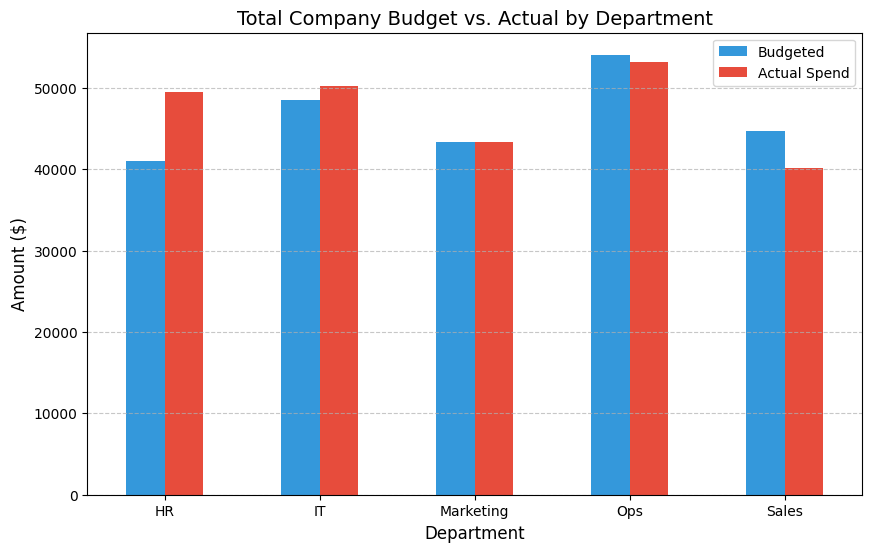

In [7]:
import matplotlib.pyplot as plt

# 1. Group the data by Department to see company-wide totals
# This is like creating a Summary Pivot Table
dept_totals = master_df.groupby('Department')[['Budget', 'Actual']].sum()

# 2. Create a grouped bar chart
# We use hex codes for professional "Corporate" colors
ax = dept_totals.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c'])

# 3. Add labels and titles for clarity
plt.title('Total Company Budget vs. Actual by Department', fontsize=14)
plt.ylabel('Amount ($)', fontsize=12)
plt.xlabel('Department', fontsize=12)
plt.xticks(rotation=0) # Keep department names horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a light grid for easier reading
plt.legend(['Budgeted', 'Actual Spend'])

# 4. Display the chart
plt.show()